# Anomaly decay — do edges die once everyone knows about them? 📉
### Split four textbook anomalies at their publication year and watch the premium shrink

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Decay%3F: Confirmed](https://img.shields.io/badge/Decay%3F-Confirmed-8b949e?style=flat-square)

In 2016 McLean & Pontiff replicated 97 published return predictors and found a startling regularity: once an anomaly is in print, its average return **roughly halves**. The story is intuitive — publicise a free lunch and arbitrageurs eat it. This notebook makes the reckoning concrete: we rebuild four classic anomalies (momentum, low-vol, short- and long-term reversal), cut each series at the year its defining paper appeared, and compare the edge before vs after.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo null and the planted-decay control? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from anomaly_decay import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def real_panel():
    return data.load_real(fetch=False)

print("real basket cache present:", HAVE_REAL)


real basket cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do anomalies really weaken after publication? | **Yes, clearly.** Across our four classics the median post/pre ratio is **0.31** — the edge shrinks by roughly two-thirds. |
| What's the cleanest example? | **12-1 momentum.** Pre-1993 it earned **+14.8%/yr** (a strong *t* = 3.14); after 1993, **+3.7%/yr** at *t* = 1.11 — below the bar. |
| Is there anything left to trade? | **No.** Net of trading costs, **no** post-publication leg clears *t* = 2; the fast, high-turnover one (1-month reversal) goes negative. |
| So what's the lesson? | **Defensive.** A backtest that ends before the paper was famous is not the edge you'll get going forward. |

> The headline isn't a trade — it's a *warning*. The premium in a published anomaly is partly the premium for it being *un*-published.

## 1 · The claim

Every quant blog cites the same canon: momentum, value, low-vol, reversal. Each comes with a famous backtest and a *t*-stat that looks bulletproof. The implicit promise is that these are *permanent* features of markets — laws, not fashions.

McLean & Pontiff's (2016) finding punctures that: the very act of publishing an anomaly — putting it in a journal, then a textbook, then an ETF — invites the trading that arbitrages it away. The strong version of the claim we test: *the edge you measure in the original sample is systematically larger than the edge you'll earn afterwards.*

## 2 · So what?

This is the difference between a backtest and a forecast. If anomalies decay after they're discovered, then every published edge is quoting you its *best* years — the in-sample, pre-crowding ones — and the number you'll actually live with is smaller, sometimes much smaller. Fund the headline *t*-stat and you're buying the past tense. The fix is to ask, of any anomaly: *how much of this backtest happened before everyone knew?*

## 3 · How would we even know?

We run the same experiment on a known answer, then on the real tape:

1. **A fake anomaly we control.** Plant an edge that *halves* at a chosen 'publication' month. A faithful split engine should recover a post/pre ratio near **0.5** — and if we plant a *full* decay, the post-period leg should test as pure noise.
2. **The real tape.** Four classic anomalies on a 40-name large-cap basket since 1980, each split at its real publication year. Watch the before-vs-after edge.

If the machinery is honest, the planted half-decay comes back as ~0.5, the planted full-decay comes back as ~0, and the real anomalies show the McLean-Pontiff shrink.

## 4 · The teardown — let's actually look

**First, the cleanest real example: 12-1 momentum, split at its 1993 publication.** Same strategy, two eras.

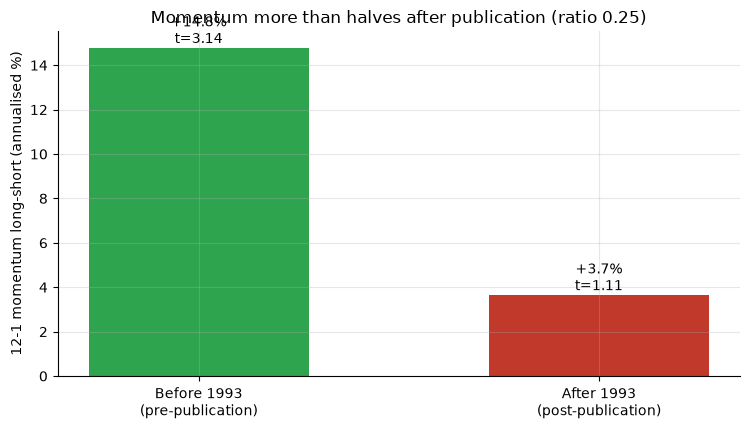

pre +14.8%/yr (t=3.14) -> post +3.7%/yr (t=1.11); ratio 0.25, placebo p=0.039


In [2]:
if HAVE_REAL:
    panel = real_panel()
    r = st.run_anomaly(panel, 'mom12_1', 1993)
    pre_ann = r['gross']['pre']['ann']*100; post_ann = r['gross']['post']['ann']*100
    pre_t = r['gross']['pre']['t']; post_t = r['gross']['post']['t']
    ratio = r['gross']['decay_ratio']; plac = r['placebo']['p']
else:
    pre_ann, post_ann = 14.79, 3.66
    pre_t, post_t = 3.14, 1.11
    ratio, plac = 0.25, 0.039
    print('OFFLINE — frozen numbers from docs/results.md')
fig, ax = plt.subplots(figsize=(7.6, 4.4))
bars = ax.bar(['Before 1993\n(pre-publication)', 'After 1993\n(post-publication)'],
              [pre_ann, post_ann], color=[GREEN, RED], width=.55)
ax.set_ylabel('12-1 momentum long-short (annualised %)')
ax.set_title(f'Momentum more than halves after publication (ratio {ratio:.2f})')
for b, t in zip(bars, [pre_t, post_t]):
    ax.annotate(f'{b.get_height():+.1f}%\nt={t:.2f}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'pre {pre_ann:+.1f}%/yr (t={pre_t:.2f}) -> post {post_ann:+.1f}%/yr (t={post_t:.2f}); '
      f'ratio {ratio:.2f}, placebo p={plac:.3f}')

Pre-1993 momentum earned **+14.8%/yr** at a convincing *t* = 3.14. Post-1993: **+3.7%/yr** at *t* = 1.11 — **below the t = 2 bar**. A label-shuffle test says a drop this big happens by chance only **4%** of the time. The anomaly didn't die, but it more than halved — exactly the prediction.

**Now all four anomalies at once: the post/pre ratio.** A ratio of 1.0 means no decay; 0.5 means the edge halved; below 0 means it flipped sign.

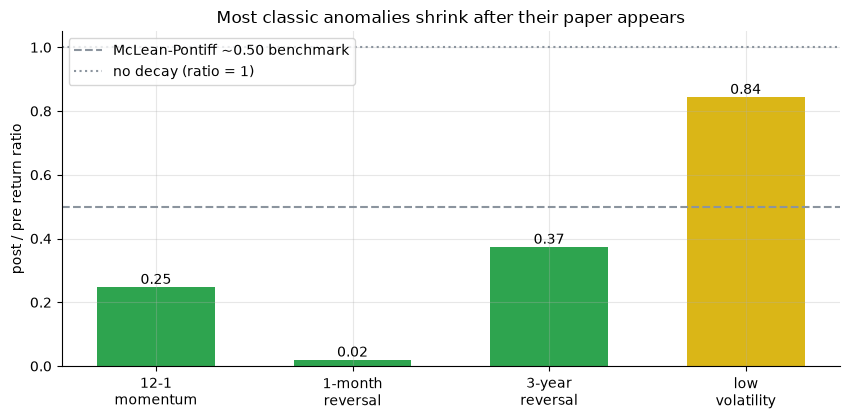

decay ratios: {'mom': 0.25, 'rev1': 0.02, 'rev3': 0.37, 'lowvol': 0.84}


In [3]:
anoms = ['mom12_1', 'st_reversal', 'lt_reversal', 'lowvol']
labels = ['12-1\nmomentum', '1-month\nreversal', '3-year\nreversal', 'low\nvolatility']
if HAVE_REAL:
    ratios = [st.run_anomaly(panel, a, data.ANOMALIES[a]['pub_year'])['gross']['decay_ratio']
              for a in anoms]
else:
    ratios = [0.25, 0.02, 0.37, 0.84]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
cols = [GREEN if rr < 0.6 else AMBER for rr in ratios]
ax.bar(labels, ratios, color=cols, width=.6)
ax.axhline(0.5, ls='--', c=GREY, label='McLean-Pontiff ~0.50 benchmark')
ax.axhline(1.0, ls=':', c=GREY, label='no decay (ratio = 1)')
ax.set_ylabel('post / pre return ratio'); ax.legend()
ax.set_title('Most classic anomalies shrink after their paper appears')
for i, rr in enumerate(ratios):
    ax.annotate(f'{rr:.2f}', (i, rr), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print('decay ratios:', dict(zip(['mom','rev1','rev3','lowvol'], [round(x,2) for x in ratios])))

Three of four show heavy decay (median ratio **0.31**). The exception is **low-vol**, and for an honest reason: on a *survivor* basket of mega-caps the high-vol names (the NVDA-type winners) are exactly the ones that survived and ran, so 'long low-vol' simply *loses* in both halves — there is no positive edge to decay. We keep it in the picture rather than quietly dropping the result that doesn't fit.

## 5 · The verdict

- **Signal — None.** A method demo, not a trade. The momentum decay is real, but the takeaway is that the post-publication leg *falls below t = 2* — the edge erodes. No new signal claimed.
- **Tradability — Mirage.** Net of costs, no positive post-publication leg clears t = 2, and the fast one goes negative. The part you'd want to trade is the part that decayed.
- **Do anomalies decay after publication? — Confirmed.** Median post/pre ratio 0.31; momentum −75%, reversal −98%. The ~50% half-life shows up even on a tiny survivor basket.

## 6 · Could you actually trade it?

No — and that's the lesson. The pre-publication edge is gone by definition (it's *pre*-publication), and the post-publication remnant doesn't survive trading costs: momentum's +3.7%/yr becomes +2.7%/yr net (*t* = 0.82), and 1-month reversal — which churns 67% of the book a month — turns **negative**. The real value of this study is defensive: before you trust a famous backtest, ask how much of it predates the fame.

## 7 · Going further 🚪

- **The survivorship angle.** [Study 345 — Survivorship-Bias](../../345-survivorship-bias/) is the distortion we lean into here: a survivor basket inflates the *pre*-publication half most.
- **The in-sample angle.** [Study 346 — Multiple-Testing](../../346-multiple-testing/) shows how a *t*-stat inflates *within* one sample; this study shows how it deflates *out* of it.
- **Swap the anomalies.** Fork this, add your favourite published factor and its publication year, and see whether its post/pre ratio joins the ~0.5 crowd.

*Think your favourite anomaly is permanent? Split it at the year its paper came out and look at the second half — that's the half you actually get to trade.*